# RAV paper figures

*Developed and written by Lorenzo Casalino (UC San Diego).*

Plotting notebook for the spike geometry analyses. Reads the per-trajectory `.txt` files produced by the Tcl analyses (value columns only; the time axis is recomputed from the frame index).

## Setup

In [1]:
# Libraries
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import seaborn as sns
from scipy.signal import find_peaks

In [2]:
# Custom colour palette (grey, orange, red, purple)
custompal = ['#999999',
             (0.977856, 0.602051, 0.241387),
             (0.85975, 0.360588, 0.406917),
             (0.669845, 0.142992, 0.582154)]

In [3]:
# Global font
pylab.rcParams.update({'font.sans-serif': 'Libre Franklin'})

In [4]:
# >>> EDIT THIS to point at the directory holding the analysis output folders <<<
# Default: the regenerated data produced by run_all.sh (source_code/results).
# To use the original published outputs instead, set:
#   path_out = '/net/gpfs-amarolab/lcasalino/CORONAVIRUS/RAV/ANALYSES'
path_out = 'results'


## Tilting angles and NTD area — distributions over the last 352 ns

Single-spike (open/closed/mutant) vs spikes-in-RAV, as filled KDEs.

Only the **last 1760 frames (≈352 ns)** of each RAV spike are used here, to approximately match the timescale sampled by the individual single-spike simulations (~400–1000 ns per replica), so the two distributions are compared over comparable amounts of simulation time.

In [5]:
# =====================================================
# PREPROCESSING FOR COMPUTING PROPERTIES OVER LAST 352 ns
# =====================================================

FRAME_DT_NS = 0.2
WINDOW_NS   = 352
N_LAST = int(WINDOW_NS / FRAME_DT_NS)   # 1760 frames

print(f"Selecting last {N_LAST} frames per spike "
      f"({WINDOW_NS} ns @ {FRAME_DT_NS} ns/frame)\n")

# -----------------------------------------------------
# FILE PATTERNS
# -----------------------------------------------------
hip_pattern   = path_out + "/HIP_TILTING_ANGLE/spike{}.HIP_TILTING_ANGLE.txt"
knee_pattern  = path_out + "/KNEE_TILTING_ANGLE/spike{}.KNEE_TILTING_ANGLE.txt"
ankle_pattern = path_out + "/ANKLE_TILTING_ANGLE/spike{}.ANKLE_TILTING_ANGLE.txt"
ntd_pattern   = path_out + "/NTD_AREA_RAV/spike{}.NTD_AREA_RAV.txt"

# File indices from 0 to 29, excluding index 6
file_indices = [i for i in range(30) if i != 6]

# -----------------------------------------------------
# INITIALIZE LISTS
# -----------------------------------------------------
hip_data_list   = []
knee_data_list  = []
ankle_data_list = []
ntd_data_list   = []

# LOAD DATA (LAST 1760 FRAMES)
# -----------------------------------------------------
for idx in file_indices:

    hip_file   = hip_pattern.format(idx)
    knee_file  = knee_pattern.format(idx)
    ankle_file = ankle_pattern.format(idx)
    ntd_file   = ntd_pattern.format(idx)

    print(f"\nSpike {idx}:")

    try:
        for label, file, data_list in [
            ("HIP",   hip_file,   hip_data_list),
            ("KNEE",  knee_file,  knee_data_list),
            ("ANKLE", ankle_file, ankle_data_list),
            ("NTD",   ntd_file,   ntd_data_list),
        ]:
            with open(file, "r") as f:
                nlines = sum(1 for _ in f)

            skip = max(nlines - N_LAST, 0)
            data = np.loadtxt(file, usecols=1, skiprows=skip, max_rows=N_LAST)
            data_list.append(data)

            if len(data) == N_LAST:
                print(f"  {label}: OK — loaded last {len(data)} frames (352 ns)")
            else:
                print(
                    f"  {label}: WARNING — loaded {len(data)} frames "
                    f"(file shorter than {N_LAST})"
                )

    except Exception as e:
        print(f"  ERROR reading spike {idx}: {e}")

# CONCATENATE
# -----------------------------------------------------
hip_combined   = np.concatenate(hip_data_list)
knee_combined  = np.concatenate(knee_data_list)
ankle_combined = np.concatenate(ankle_data_list)
ntd_combined   = np.concatenate(ntd_data_list)

# GLOBAL SANITY CHECKS
# -----------------------------------------------------
expected = len(file_indices) * N_LAST

print("\n================ SANITY CHECKS ================")
print(f"Expected frames per observable: {expected}")

print(f"Length of HIP RAV data:   {len(hip_combined)} "
      f"(Δ = {len(hip_combined) - expected})")
print(f"Length of KNEE RAV data:  {len(knee_combined)} "
      f"(Δ = {len(knee_combined) - expected})")
print(f"Length of ANKLE RAV data: {len(ankle_combined)} "
      f"(Δ = {len(ankle_combined) - expected})")
print(f"Length of NTD RAV data:   {len(ntd_combined)} "
      f"(Δ = {len(ntd_combined) - expected})")

for label, data in zip(
    ["HIP", "KNEE", "ANKLE", "NTD"],
    [hip_combined, knee_combined, ankle_combined, ntd_combined]
):
    if np.any(data < 0):
        print(f"There are negative numbers in the {label} data.")
    else:
        print(f"There are no negative numbers in the {label} data.")

Selecting last 1760 frames per spike (352 ns @ 0.2 ns/frame)


Spike 0:
  HIP: OK — loaded last 1760 frames (352 ns)
  KNEE: OK — loaded last 1760 frames (352 ns)
  ANKLE: OK — loaded last 1760 frames (352 ns)
  NTD: OK — loaded last 1760 frames (352 ns)

Spike 1:
  HIP: OK — loaded last 1760 frames (352 ns)
  KNEE: OK — loaded last 1760 frames (352 ns)
  ANKLE: OK — loaded last 1760 frames (352 ns)
  NTD: OK — loaded last 1760 frames (352 ns)

Spike 2:
  HIP: OK — loaded last 1760 frames (352 ns)
  KNEE: OK — loaded last 1760 frames (352 ns)
  ANKLE: OK — loaded last 1760 frames (352 ns)
  NTD: OK — loaded last 1760 frames (352 ns)

Spike 3:
  HIP: OK — loaded last 1760 frames (352 ns)
  KNEE: OK — loaded last 1760 frames (352 ns)
  ANKLE: OK — loaded last 1760 frames (352 ns)
  NTD: OK — loaded last 1760 frames (352 ns)

Spike 4:
  HIP: OK — loaded last 1760 frames (352 ns)
  KNEE: OK — loaded last 1760 frames (352 ns)
  ANKLE: OK — loaded last 1760 frames (352 ns)
  NTD: OK — loaded

There are no negative numbers in the data.


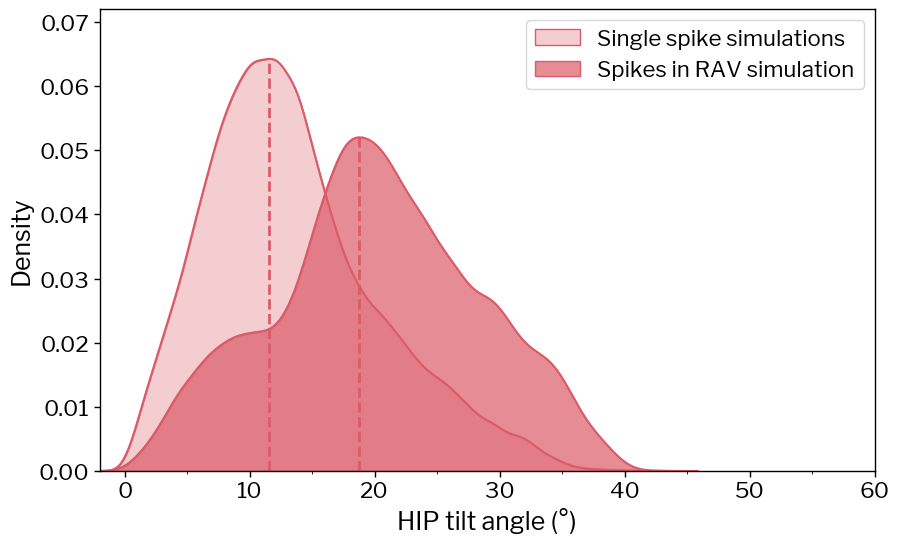

In [6]:
###################################
# HIP LAST 352 #
###################################
# SET FONT #
# to clear matplot lib cache: rm ~/.cache/matplotlib -fr

params = {   'font.sans-serif': 'Libre Franklin',
         }
pylab.rcParams.update(params)

fig, ax = plt.subplots()

# Load and process the data for each system
hip_ss = np.loadtxt(path_out+"/HIP_TILTING_ANGLE_SINGLESPIKE/concatenated_reps_tilting.txt")[:, 1]
hip_rav = hip_combined   # <-- USE NEW RAV DATASET BUILT FROM SOURCE FILES

# Check if there are any negative numbers
if np.any(hip_ss < 0):
    print("There are negative numbers in the data.")
else:
    print("There are no negative numbers in the data.")

# PLOT KERNEL P DENSITIES FILLED
sns.kdeplot(hip_ss, fill=True, label="Single spike simulations",
            color=custompal[2], alpha=0.3, bw_adjust=1)
sns.kdeplot(hip_rav, fill=True, label="Spikes in RAV simulation",
            color=custompal[2], alpha=0.7, bw_adjust=1)

# PLOT CONTOURS OF P K DENSITIES
sns.kdeplot(hip_ss, fill=False, color=custompal[2], bw_adjust=1)
sns.kdeplot(hip_rav, fill=False, color=custompal[2], bw_adjust=1)

# DETERMINE PEAKS of DENSITIES (HIGHEST PEAK ONLY)
for i, line in enumerate(ax.lines):
    xs = line.get_xdata()
    ys = line.get_ydata()
    
    peaks, _ = find_peaks(ys)
    
    if len(peaks) > 0:
        highest_peak_idx = peaks[np.argmax(ys[peaks])]
        ax.vlines(xs[highest_peak_idx], 0, ys[highest_peak_idx],
                  linestyle='dashed', color=line.get_color(), lw=2)
    else:
        print(f"No peaks found for line {i}.")

# Set axes width
for axis in ['top','bottom','left','right']:
  ax.spines[axis].set_linewidth(1)

# Set labels and ticks
ax.set_xlabel("HIP tilt angle (°)", size=18)

ax.set_xlim([-2,60])
ax.xaxis.set_minor_locator(MultipleLocator(5))
ax.xaxis.set_major_locator(MultipleLocator(10))

ax.set_ylabel('Density', size=18)
ax.set_ylim([0,0.072])

ax.tick_params(which='major', labelsize=16, width=1, length=4)
plt.rcParams["axes.labelweight"] = "bold"

# Legend
ax.legend(loc='upper right', prop={'size': 16})

# Save Figure
fig.set_size_inches(10, 6)
fig.savefig(path_out+'/tilting_HIP_ss_vs_RAVlast352_wide_v3.png',
            bbox_inches="tight", transparent=True, dpi=600)

There are no negative numbers in the data.


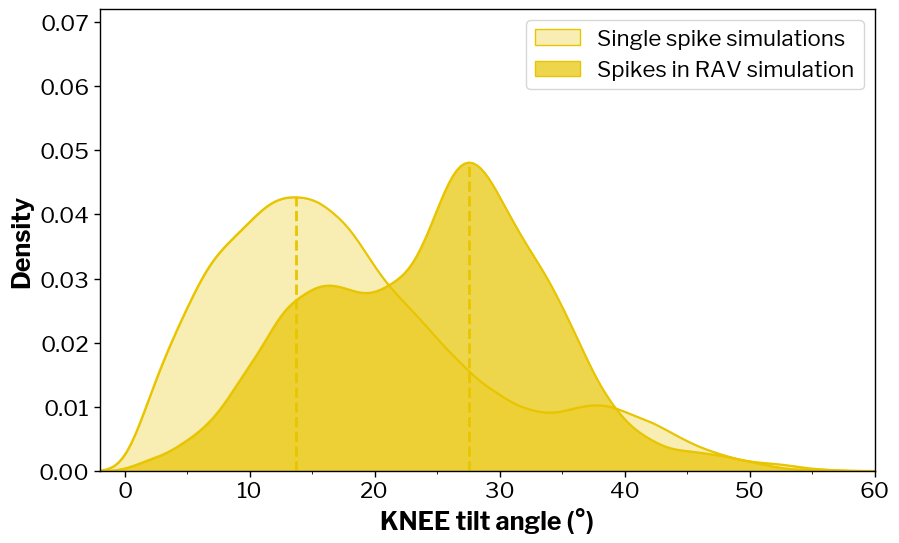

In [7]:
###################################
# KNEE LAST 352 ns#
###################################
# SET FONT #
# to clear matplot lib cache: rm ~/.cache/matplotlib -fr

params = {   'font.sans-serif': 'Libre Franklin',
         }
pylab.rcParams.update(params)

fig, ax = plt.subplots()

# -----------------------------
# COLOR
# -----------------------------
yellow = (0.91, 0.774, 0.0)

# Load and process the data for each system

knee_ss = np.loadtxt(path_out+"/KNEE_TILTING_ANGLE_SINGLESPIKE/concatenated_reps_tilting.txt")[:, 1]
knee_rav = knee_combined

# Check if there are any negative numbers
if np.any(knee_ss < 0):
    print("There are negative numbers in the data.")
else:
    print("There are no negative numbers in the data.")

# PLOT KERNEL P DENSITIES FILLED
sns.kdeplot(knee_ss, fill=True, label="Single spike simulations",
            color=yellow, alpha=0.3, bw_adjust=1)
sns.kdeplot(knee_rav, fill=True, label="Spikes in RAV simulation",
            color=yellow, alpha=0.7, bw_adjust=1)

# PLOT CONTOURS OF P K DENSITIES
sns.kdeplot(knee_ss, fill=False, color=yellow, bw_adjust=1)
sns.kdeplot(knee_rav, fill=False, color=yellow, bw_adjust=1)

# DETERMINE PEAKS of DENSITIES (HIGHEST PEAK ONLY)
for i, line in enumerate(ax.lines):
    xs = line.get_xdata()
    ys = line.get_ydata()
    
    peaks, _ = find_peaks(ys)
    
    if len(peaks) > 0:
        highest_peak_idx = peaks[np.argmax(ys[peaks])]
        ax.vlines(xs[highest_peak_idx], 0, ys[highest_peak_idx],
                  linestyle='dashed', color=line.get_color(), lw=2)
    else:
        print(f"No peaks found for line {i}.")

# Set axes width
for axis in ['top','bottom','left','right']:
  ax.spines[axis].set_linewidth(1)

# Set labels and ticks
ax.set_xlabel("KNEE tilt angle (°)", size=18)

ax.set_xlim([-2,60])
ax.xaxis.set_minor_locator(MultipleLocator(5))
ax.xaxis.set_major_locator(MultipleLocator(10))

ax.set_ylabel('Density', size=18)
ax.set_ylim([0,0.072])

ax.tick_params(which='major', labelsize=16, width=1, length=4)
plt.rcParams["axes.labelweight"] = "bold"

# Legend
ax.legend(loc='upper right', prop={'size': 16})

# Save Figure
fig.set_size_inches(10, 6)
fig.savefig(path_out+'/tilting_KNEE_ss_vs_RAVlast352_wide_v3.png',
            bbox_inches="tight", transparent=True, dpi=600)

There are no negative numbers in the data.


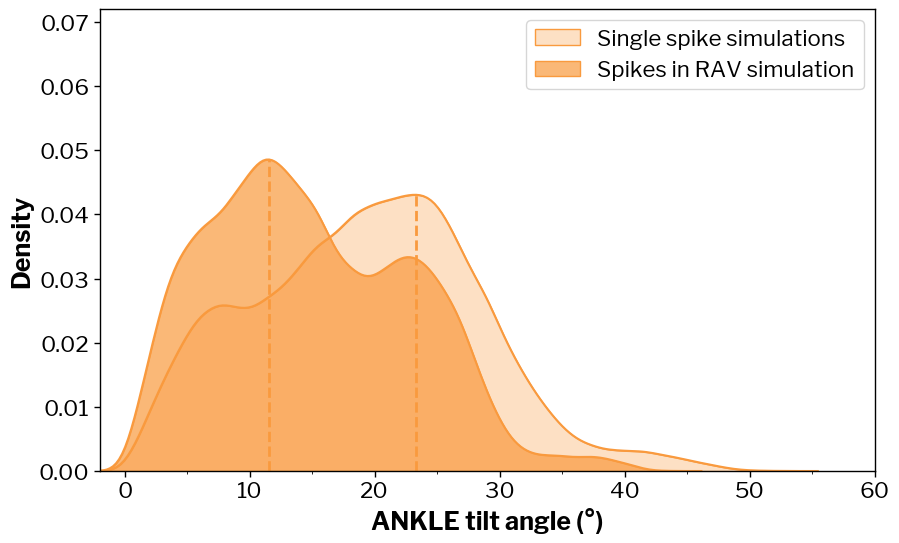

In [8]:
###################################
# ANKLE LAST 352 ns #
###################################
# SET FONT #
# to clear matplot lib cache: rm ~/.cache/matplotlib -fr

params = {   'font.sans-serif': 'Libre Franklin',
         }
pylab.rcParams.update(params)

fig, ax = plt.subplots()
# Load and process the data for each system

ankle_ss = np.loadtxt(path_out+"/ANKLE_TILTING_ANGLE_SINGLESPIKE/concatenated_reps_tilting.txt")[:, 1]
ankle_rav = ankle_combined

# Check if there are any negative numbers
if np.any(ankle_ss < 0):
    print("There are negative numbers in the data.")
else:
    print("There are no negative numbers in the data.")

# PLOT KERNEL P DENSITIES FILLED
sns.kdeplot(ankle_ss, fill=True, label="Single spike simulations", color=custompal[1], alpha=0.3, bw_adjust=1)
sns.kdeplot(ankle_rav, fill=True, label="Spikes in RAV simulation", color=custompal[1], alpha=0.7, bw_adjust=1)

# PLOT CONTOURS OF P K DENSITIES
sns.kdeplot(ankle_ss, fill=False, color=custompal[1], bw_adjust=1)
sns.kdeplot(ankle_rav, fill=False, color=custompal[1], bw_adjust=1)

# DETERMINE PEAKS of DENSITIES

for i, line in enumerate(ax.lines):
    # Get x and y data from the kernel density estimate
    xs = line.get_xdata()
    ys = line.get_ydata()
    
    # Find all peaks in the density estimate
    peaks, _ = find_peaks(ys)
    
    if len(peaks) > 0:
        # Sort peaks by y value (height) and get indices of the sorted peaks
        sorted_peaks = sorted(peaks, key=lambda idx: ys[idx], reverse=True)
        
        highest_peak_idx = sorted_peaks[0]
        ax.vlines(xs[highest_peak_idx], 0, ys[highest_peak_idx], linestyle='dashed', color=line.get_color(), lw=2)
        
    else:
        print(f"No peaks found for line {i}.")

# Set axes width
for axis in ['top','bottom','left','right']:
  ax.spines[axis].set_linewidth(1)

# Set y labels and ticks
#ax.set_xlabel('Molecular time to opening event\n(WE iteration n. '+r"$\times$ "+r"$\tau$, ns)", size=16)
ax.set_xlabel("ANKLE tilt angle (°)", size=18)

ax.set_xlim([-2,60])
ax.xaxis.set_minor_locator(MultipleLocator(5))
ax.xaxis.set_major_locator(MultipleLocator(10))
#plt.xticks(rotation=90)

# Set y labels and ticks
ax.set_ylabel('Density', size=18)
ax.set_ylim([0,0.072])

# Set ticks size
ax.tick_params(which='major', labelsize= 16, width=1, length=4)
plt.rcParams["axes.labelweight"] = "bold"

# Legend
ax.legend(loc='upper right', prop={'size': 16})

# Save Figure
fig.set_size_inches(10, 6)
fig.savefig(path_out+'/tilting_ANKLE_ss_vs_RAVlast352_wide_v3.png', bbox_inches="tight", transparent=True, dpi=600)

There are no negative numbers in the data.


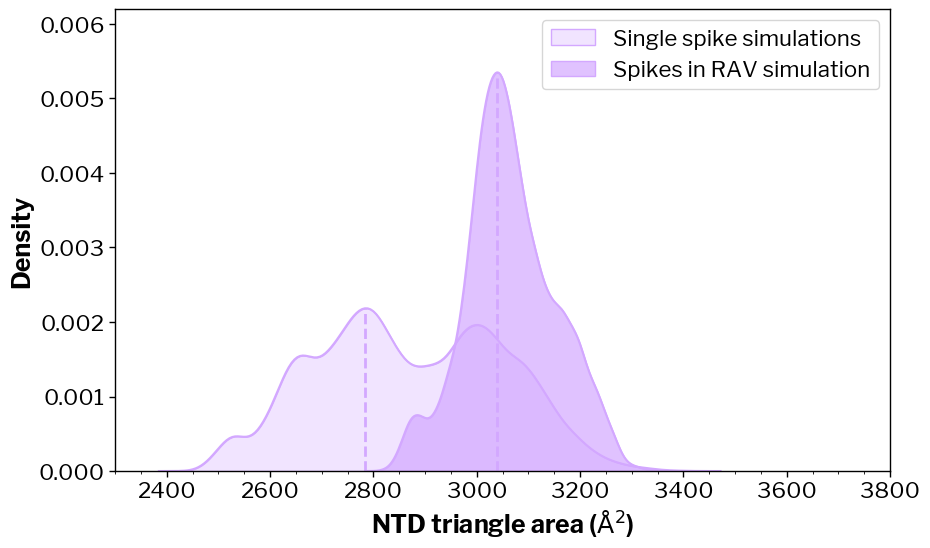

In [9]:
###################################
# NTD tirangle area last 352 ns #
###################################
# SET FONT #
# to clear matplot lib cache: rm ~/.cache/matplotlib -fr

params = {   'font.sans-serif': 'Libre Franklin',
         }
pylab.rcParams.update(params)

# -----------------------------
# COLOR (as requested)
# -----------------------------
mauve = (0.828, 0.657, 1.0)

fig, ax = plt.subplots()

# LOAD DATA
ntd_ss = np.loadtxt(path_out+"/NTD_AREA_SINGLESPIKE/concatenated_reps_area.txt")[:, 1]
ntd_rav = ntd_combined

# Check if there are any negative numbers
if np.any(ntd_ss < 0):
    print("There are negative numbers in the data.")
else:
    print("There are no negative numbers in the data.")

# PLOT KERNEL P DENSITIES FILLED
sns.kdeplot(ntd_ss, fill=True, label="Single spike simulations", color=mauve, alpha=0.3, bw_adjust=1)
sns.kdeplot(ntd_rav, fill=True, label="Spikes in RAV simulation", color=mauve, alpha=0.7, bw_adjust=1)

# PLOT CONTOURS OF P K DENSITIES
sns.kdeplot(ntd_ss, fill=False, color=mauve, bw_adjust=1)
sns.kdeplot(ntd_rav, fill=False, color=mauve, bw_adjust=1)

# DETERMINE PEAKS of DENSITIES

for i, line in enumerate(ax.lines):
    # Get x and y data from the kernel density estimate
    xs = line.get_xdata()
    ys = line.get_ydata()
    
    # Find all peaks in the density estimate
    peaks, _ = find_peaks(ys)
    
    if len(peaks) > 0:
        # Sort peaks by y value (height) and get indices of the sorted peaks
        sorted_peaks = sorted(peaks, key=lambda idx: ys[idx], reverse=True)
        
        highest_peak_idx = sorted_peaks[0]
        ax.vlines(xs[highest_peak_idx], 0, ys[highest_peak_idx], linestyle='dashed', color=line.get_color(), lw=2)
        
    else:
        print(f"No peaks found for line {i}.")

# Set axes width
for axis in ['top','bottom','left','right']:
  ax.spines[axis].set_linewidth(1)

# Set y labels and ticks
#ax.set_xlabel('Molecular time to opening event\n(WE iteration n. '+r"$\times$ "+r"$\tau$, ns)", size=16)
ax.set_xlabel("NTD triangle area ($\mathrm{\AA}^2$)", size=18)

ax.set_xlim([2300,3800])
ax.xaxis.set_minor_locator(MultipleLocator(50))
ax.xaxis.set_major_locator(MultipleLocator(200))
#plt.xticks(rotation=90)

# Set y labels and ticks
ax.set_ylabel('Density', size=18)
ax.set_ylim([0,0.0062])

# Set ticks size
ax.tick_params(which='major', labelsize= 16, width=1, length=4)
plt.rcParams["axes.labelweight"] = "bold"

# Legend
ax.legend(loc='upper right', prop={'size': 16})

# Save Figure
fig.set_size_inches(10, 6)
fig.savefig(path_out+'/NTD_area_ss_vs_RAVlast352_wide_v3.png', bbox_inches="tight", transparent=True, dpi=600)

## RBD–central-helix distance — KDEs in 4 time blocks

Chains A, B and C analysed separately.

In [10]:
# =====================================================
# PREPROCESSING — RBD–CH DISTANCE (RAV), 4 TIME BLOCKS
# =====================================================

FRAME_DT_NS = 0.2
N_BLOCKS    = 4

print(f"Using dt = {FRAME_DT_NS} ns/frame")
print(f"Splitting each spike into {N_BLOCKS} equal time blocks\n")

# -----------------------------------------------------
# FILE PATTERN
# -----------------------------------------------------
rbd_pattern = path_out + "/RBD_CH_DIST_RAV/spike{}.RBD_CH_DIST_RAV.txt"

# File indices from 0 to 29, excluding index 6
file_indices = [i for i in range(30) if i != 6]

# -----------------------------------------------------
# INITIALIZE LISTS
# -----------------------------------------------------
block_data = {i: [] for i in range(1, N_BLOCKS + 1)}

# LOAD DATA (PER SPIKE)
# -----------------------------------------------------
for idx in file_indices:

    rbd_file = rbd_pattern.format(idx)
    print(f"\nSpike {idx}:")

    try:
        # Count total frames
        with open(rbd_file, "r") as f:
            nlines = sum(1 for _ in f)

        block_size = nlines // N_BLOCKS
        block_ns   = block_size * FRAME_DT_NS

        print(
            f"  Total frames: {nlines} "
            f"({nlines * FRAME_DT_NS:.1f} ns)"
        )
        print(
            f"  Frames per block: {block_size} "
            f"({block_ns:.1f} ns)"
        )

        # Load Chain A ONLY
        rbd_chainA = np.loadtxt(rbd_file, usecols=1)

        # ----------------------
        # SPLIT INTO BLOCKS
        # ----------------------
        for b in range(N_BLOCKS):
            start = b * block_size
            end   = (b + 1) * block_size

            block_slice = rbd_chainA[start:end]
            block_data[b + 1].append(block_slice)

            t0 = start * FRAME_DT_NS
            t1 = end   * FRAME_DT_NS

            print(
                f"  Block {b+1}: "
                f"frames {start} → {end-1} "
                f"({t0:.1f}–{t1:.1f} ns, n = {len(block_slice)})"
            )

    except Exception as e:
        print(f"  ERROR reading spike {idx}: {e}")

# -----------------------------------------------------
# CONCATENATE ACROSS SPIKES
# -----------------------------------------------------
block1 = np.concatenate(block_data[1])
block2 = np.concatenate(block_data[2])
block3 = np.concatenate(block_data[3])
block4 = np.concatenate(block_data[4])

# GLOBAL SANITY CHECKS
# -----------------------------------------------------
expected_per_block = len(file_indices) * block_size

print("\n================ SANITY CHECKS ================")
print(f"Expected frames per block: {expected_per_block}")

for i, block in zip(
    [1, 2, 3, 4],
    [block1, block2, block3, block4]
):
    print(
        f"Block {i}: length = {len(block)} "
        f"(Δ = {len(block) - expected_per_block})"
    )

    if np.any(block < 0):
        print(f"  WARNING: negative values in Block {i}")
    else:
        print(f"  OK: no negative values in Block {i}")

Using dt = 0.2 ns/frame
Splitting each spike into 4 equal time blocks


Spike 0:
  Total frames: 2530 (506.0 ns)
  Frames per block: 632 (126.4 ns)
  Block 1: frames 0 → 631 (0.0–126.4 ns, n = 632)
  Block 2: frames 632 → 1263 (126.4–252.8 ns, n = 632)
  Block 3: frames 1264 → 1895 (252.8–379.2 ns, n = 632)
  Block 4: frames 1896 → 2527 (379.2–505.6 ns, n = 632)

Spike 1:
  Total frames: 2530 (506.0 ns)
  Frames per block: 632 (126.4 ns)
  Block 1: frames 0 → 631 (0.0–126.4 ns, n = 632)
  Block 2: frames 632 → 1263 (126.4–252.8 ns, n = 632)
  Block 3: frames 1264 → 1895 (252.8–379.2 ns, n = 632)
  Block 4: frames 1896 → 2527 (379.2–505.6 ns, n = 632)

Spike 2:
  Total frames: 2530 (506.0 ns)
  Frames per block: 632 (126.4 ns)
  Block 1: frames 0 → 631 (0.0–126.4 ns, n = 632)
  Block 2: frames 632 → 1263 (126.4–252.8 ns, n = 632)
  Block 3: frames 1264 → 1895 (252.8–379.2 ns, n = 632)
  Block 4: frames 1896 → 2527 (379.2–505.6 ns, n = 632)

Spike 3:
  Total frames: 2530 (506.0 ns)
  Fra

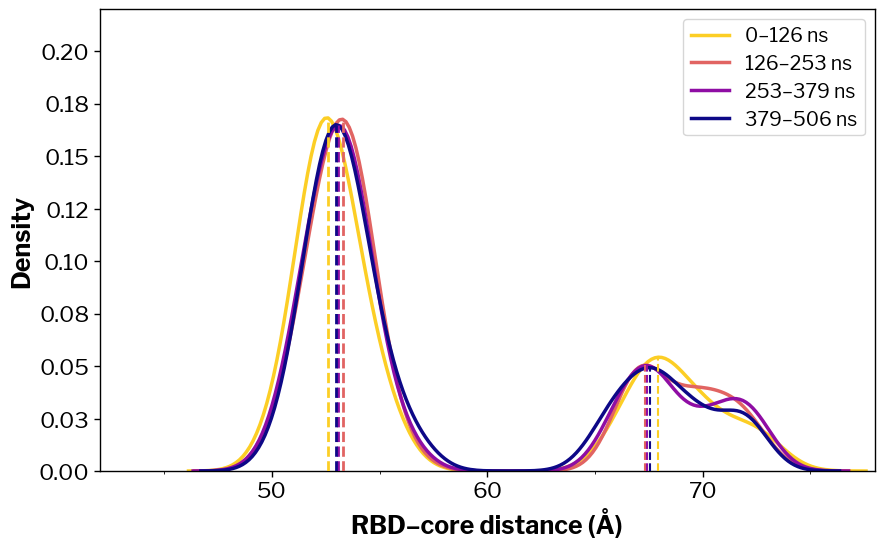

In [11]:
###################################
# RAV RBD–CH — 4 TIME BLOCKS (A)
###################################

# =========================
# USER SETTINGS
# =========================
FRAME_DT_NS = 0.2          # ns per frame
BW_ADJUST   = 1.0
X_LIM       = (42, 78)
Y_LIM       = (0, 0.22)

LINEWIDTH   = 2.5          # thicker KDE lines

# block_size MUST come from preprocessing
# block1, block2, block3, block4 must already exist

# =========================
# FONT
# =========================
params = {'font.sans-serif': 'Libre Franklin'}
pylab.rcParams.update(params)

fig, ax = plt.subplots()

# DATA
# =========================
blocks = [block1, block2, block3, block4]

# TIME LABELS (ns)
# =========================
block_ns = block_size * FRAME_DT_NS

labels = [
    f"{0:.0f}–{block_ns:.0f} ns",
    f"{block_ns:.0f}–{2*block_ns:.0f} ns",
    f"{2*block_ns:.0f}–{3*block_ns:.0f} ns",
    f"{3*block_ns:.0f}–{4*block_ns:.0f} ns",
]

# COLORS — TRUNCATED PLASMA_R
# =========================

base_cmap = mpl.colormaps["plasma_r"]

# sample safely away from bright yellow
sample_points = np.linspace(0.1, 1, 4)
colors = [base_cmap(p) for p in sample_points]

# =========================
# KDE PLOTS — LINES ONLY
# =========================
for block, label, color in zip(blocks, labels, colors):

    sns.kdeplot(
        block,
        fill=False,
        color=color,
        bw_adjust=BW_ADJUST,
        linewidth=LINEWIDTH,
        label=label,
        ax=ax
    )

# PEAKS — HIGHEST + SECOND
# =========================
for line in ax.lines:
    xs = line.get_xdata()
    ys = line.get_ydata()

    peaks, _ = find_peaks(ys)
    if len(peaks) == 0:
        continue

    sorted_peaks = peaks[np.argsort(ys[peaks])[::-1]]

    # highest peak
    i0 = sorted_peaks[0]
    ax.vlines(
        xs[i0], 0, ys[i0],
        linestyle='dashed',
        color=line.get_color(),
        lw=2,
        zorder=10
    )

    # second-highest peak
    if len(sorted_peaks) > 1:
        i1 = sorted_peaks[1]
        ax.vlines(
            xs[i1], 0, ys[i1],
            linestyle='dashed',
            color=line.get_color(),
            lw=1.5,
            zorder=9
        )

# =========================
# AXES STYLING (HIP STYLE)
# =========================
for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(1)

ax.set_xlabel("RBD–core distance (Å)", size=18)
ax.set_ylabel("Density", size=18)

ax.set_xlim(X_LIM)
ax.set_ylim(Y_LIM)

ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(5))

ax.tick_params(which='major', labelsize=16, width=1, length=4)
plt.rcParams["axes.labelweight"] = "bold"

# LEGEND & EXPORT
# =========================
ax.legend(loc='upper right', prop={'size': 14})

fig.set_size_inches(10, 6)
fig.savefig(
    path_out + "/RBD_CH_RAV_4timeblocks_chainA_viridis_lines.png",
    bbox_inches="tight",
    transparent=True,
    dpi=600
)

In [12]:
############################################
# PREPROCESSING — RBD–CH (RAV), CHAIN B
############################################

FRAME_DT_NS = 0.2
N_BLOCKS    = 4

rbd_pattern = path_out + "/RBD_CH_DIST_RAV/spike{}.RBD_CH_DIST_RAV.txt"
file_indices = [i for i in range(30) if i != 6]

block_data = {i: [] for i in range(1, N_BLOCKS + 1)}

for idx in file_indices:

    rbd_file = rbd_pattern.format(idx)
    print(f"\nSpike {idx} (Chain B):")

    try:
        with open(rbd_file, "r") as f:
            nlines = sum(1 for _ in f)

        block_size = nlines // N_BLOCKS
        block_ns   = block_size * FRAME_DT_NS

        print(
            f"  Total frames: {nlines} "
            f"({nlines * FRAME_DT_NS:.1f} ns)"
        )

        # ----------------------
        # LOAD CHAIN B
        # ----------------------
        rbd_chainB = np.loadtxt(rbd_file, usecols=2)

        for b in range(N_BLOCKS):
            start = b * block_size
            end   = (b + 1) * block_size

            slice_ = rbd_chainB[start:end]
            block_data[b + 1].append(slice_)

            print(
                f"  Block {b+1}: frames {start} → {end-1} "
                f"({start*FRAME_DT_NS:.1f}–{end*FRAME_DT_NS:.1f} ns, "
                f"n = {len(slice_)})"
            )

    except Exception as e:
        print(f"  ERROR reading spike {idx}: {e}")

# CONCATENATE
block1_B = np.concatenate(block_data[1])
block2_B = np.concatenate(block_data[2])
block3_B = np.concatenate(block_data[3])
block4_B = np.concatenate(block_data[4])

print("\n[SANITY CHECK — CHAIN B]")
for i, blk in enumerate([block1_B, block2_B, block3_B, block4_B], start=1):
    print(f"Block {i} length: {len(blk)}")


Spike 0 (Chain B):
  Total frames: 2530 (506.0 ns)
  Block 1: frames 0 → 631 (0.0–126.4 ns, n = 632)
  Block 2: frames 632 → 1263 (126.4–252.8 ns, n = 632)
  Block 3: frames 1264 → 1895 (252.8–379.2 ns, n = 632)
  Block 4: frames 1896 → 2527 (379.2–505.6 ns, n = 632)

Spike 1 (Chain B):
  Total frames: 2530 (506.0 ns)
  Block 1: frames 0 → 631 (0.0–126.4 ns, n = 632)
  Block 2: frames 632 → 1263 (126.4–252.8 ns, n = 632)
  Block 3: frames 1264 → 1895 (252.8–379.2 ns, n = 632)
  Block 4: frames 1896 → 2527 (379.2–505.6 ns, n = 632)

Spike 2 (Chain B):
  Total frames: 2530 (506.0 ns)
  Block 1: frames 0 → 631 (0.0–126.4 ns, n = 632)
  Block 2: frames 632 → 1263 (126.4–252.8 ns, n = 632)
  Block 3: frames 1264 → 1895 (252.8–379.2 ns, n = 632)
  Block 4: frames 1896 → 2527 (379.2–505.6 ns, n = 632)

Spike 3 (Chain B):
  Total frames: 2530 (506.0 ns)
  Block 1: frames 0 → 631 (0.0–126.4 ns, n = 632)
  Block 2: frames 632 → 1263 (126.4–252.8 ns, n = 632)
  Block 3: frames 1264 → 1895 (252.8

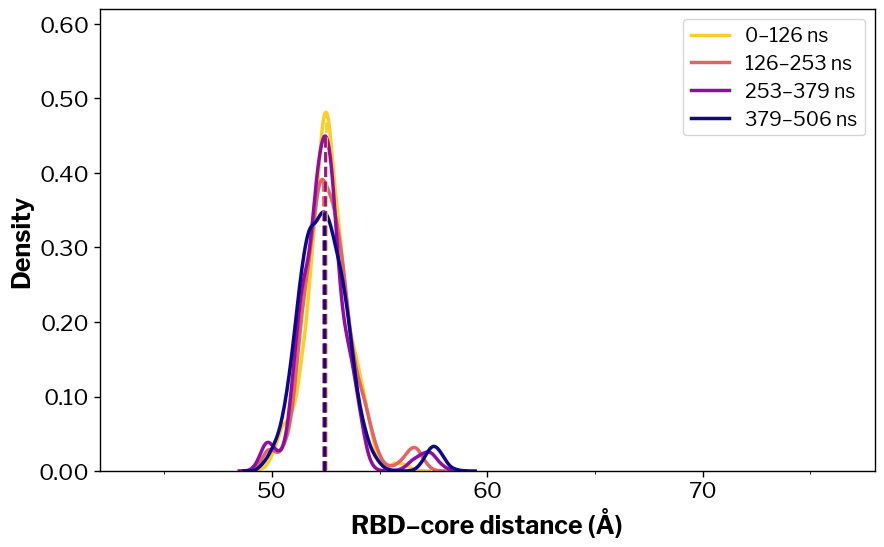

In [13]:
###################################
# RAV RBD–CH — 4 TIME BLOCKS (B)
###################################

# =========================
# USER SETTINGS
# =========================
FRAME_DT_NS = 0.2
BW_ADJUST   = 1.0
X_LIM       = (42, 78)
Y_LIM       = (0, 0.62)
LINEWIDTH   = 2.5

# FONT
# =========================
params = {'font.sans-serif': 'Libre Franklin'}
pylab.rcParams.update(params)

fig, ax = plt.subplots()

# DATA — CHAIN B
# =========================
blocks = [block1_B, block2_B, block3_B, block4_B]

# TIME LABELS (ns)
# =========================
block_ns = block_size * FRAME_DT_NS
labels = [
    f"{0:.0f}–{block_ns:.0f} ns",
    f"{block_ns:.0f}–{2*block_ns:.0f} ns",
    f"{2*block_ns:.0f}–{3*block_ns:.0f} ns",
    f"{3*block_ns:.0f}–{4*block_ns:.0f} ns",
]

# COLORS — PLASMA_R (TRUNCATED)
# =========================
base_cmap = mpl.colormaps["plasma_r"]
sample_points = np.linspace(0.1, 1.0, 4)
colors = [base_cmap(p) for p in sample_points]

# KDE PLOTS — LINES ONLY
# =========================
for block, label, color in zip(blocks, labels, colors):
    sns.kdeplot(
        block,
        fill=False,
        color=color,
        bw_adjust=BW_ADJUST,
        linewidth=LINEWIDTH,
        label=label,
        ax=ax
    )

# PEAKS — HIGHEST + SECOND
# =========================
for line in ax.lines:
    xs = line.get_xdata()
    ys = line.get_ydata()

    peaks, _ = find_peaks(ys)
    if len(peaks) == 0:
        continue

    sorted_peaks = peaks[np.argsort(ys[peaks])[::-1]]

    ax.vlines(xs[sorted_peaks[0]], 0, ys[sorted_peaks[0]],
              linestyle='dashed', color=line.get_color(), lw=2, zorder=10)

   
# AXES STYLING
# =========================
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1)

ax.set_xlabel("RBD–core distance (Å)", size=18)
ax.set_ylabel("Density", size=18)
ax.set_xlim(X_LIM)
ax.set_ylim(Y_LIM)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(5))
ax.tick_params(which='major', labelsize=16, width=1, length=4)
plt.rcParams["axes.labelweight"] = "bold"

# LEGEND & SAVE
# =========================
ax.legend(loc='upper right', prop={'size': 14})
fig.set_size_inches(10, 6)
fig.savefig(
    path_out + "/RBD_CH_RAV_4timeblocks_chainB_plasmaR_lines.png",
    bbox_inches="tight",
    transparent=True,
    dpi=600
)

In [14]:
# =====================================================
# PREPROCESSING — RBD–CH DISTANCE (RAV), CHAIN C
# =====================================================

FRAME_DT_NS = 0.2
N_BLOCKS    = 4

rbd_pattern = path_out + "/RBD_CH_DIST_RAV/spike{}.RBD_CH_DIST_RAV.txt"

# Spike indices (exclude spike 6)
file_indices = [i for i in range(30) if i != 6]

# -----------------------------------------------------
# INITIALIZE BLOCK LISTS
# -----------------------------------------------------
block_data = {i: [] for i in range(1, N_BLOCKS + 1)}

# LOAD + SLICE PER SPIKE (CHAIN C)
# -----------------------------------------------------
for idx in file_indices:

    rbd_file = rbd_pattern.format(idx)
    print(f"\nSpike {idx} — Chain C")

    try:
        # Count frames
        with open(rbd_file, "r") as f:
            nlines = sum(1 for _ in f)

        block_size = nlines // N_BLOCKS
        total_ns   = nlines * FRAME_DT_NS
        block_ns   = block_size * FRAME_DT_NS

        print(f"  Total frames: {nlines} ({total_ns:.1f} ns)")
        print(f"  Frames per block: {block_size} ({block_ns:.1f} ns)")

        # ----------------------
        # LOAD CHAIN C (col 3)
        # ----------------------
        rbd_chainC = np.loadtxt(rbd_file, usecols=3)

        # SPLIT INTO BLOCKS
        # ----------------------
        for b in range(N_BLOCKS):
            start = b * block_size
            end   = (b + 1) * block_size

            slice_ = rbd_chainC[start:end]
            block_data[b + 1].append(slice_)

            print(
                f"  Block {b+1}: frames {start} → {end-1} "
                f"({start*FRAME_DT_NS:.1f}–{end*FRAME_DT_NS:.1f} ns, "
                f"n = {len(slice_)})"
            )

    except Exception as e:
        print(f"  ERROR reading spike {idx}: {e}")

# -----------------------------------------------------
# CONCATENATE ACROSS SPIKES
# -----------------------------------------------------
block1_C = np.concatenate(block_data[1])
block2_C = np.concatenate(block_data[2])
block3_C = np.concatenate(block_data[3])
block4_C = np.concatenate(block_data[4])

# SANITY CHECKS
# -----------------------------------------------------
expected = len(file_indices) * block_size

print("\n================ SANITY CHECKS (CHAIN C) ================")
for i, blk in enumerate(
    [block1_C, block2_C, block3_C, block4_C], start=1
):
    print(
        f"Block {i}: length = {len(blk)} "
        f"(Δ = {len(blk) - expected})"
    )

    if np.any(blk < 0):
        print(f"  WARNING: negative values in Block {i}")
    else:
        print(f"  OK: no negative values in Block {i}")


Spike 0 — Chain C
  Total frames: 2530 (506.0 ns)
  Frames per block: 632 (126.4 ns)
  Block 1: frames 0 → 631 (0.0–126.4 ns, n = 632)
  Block 2: frames 632 → 1263 (126.4–252.8 ns, n = 632)
  Block 3: frames 1264 → 1895 (252.8–379.2 ns, n = 632)
  Block 4: frames 1896 → 2527 (379.2–505.6 ns, n = 632)

Spike 1 — Chain C
  Total frames: 2530 (506.0 ns)
  Frames per block: 632 (126.4 ns)
  Block 1: frames 0 → 631 (0.0–126.4 ns, n = 632)
  Block 2: frames 632 → 1263 (126.4–252.8 ns, n = 632)
  Block 3: frames 1264 → 1895 (252.8–379.2 ns, n = 632)
  Block 4: frames 1896 → 2527 (379.2–505.6 ns, n = 632)

Spike 2 — Chain C
  Total frames: 2530 (506.0 ns)
  Frames per block: 632 (126.4 ns)
  Block 1: frames 0 → 631 (0.0–126.4 ns, n = 632)
  Block 2: frames 632 → 1263 (126.4–252.8 ns, n = 632)
  Block 3: frames 1264 → 1895 (252.8–379.2 ns, n = 632)
  Block 4: frames 1896 → 2527 (379.2–505.6 ns, n = 632)

Spike 3 — Chain C
  Total frames: 2530 (506.0 ns)
  Frames per block: 632 (126.4 ns)
  Blo

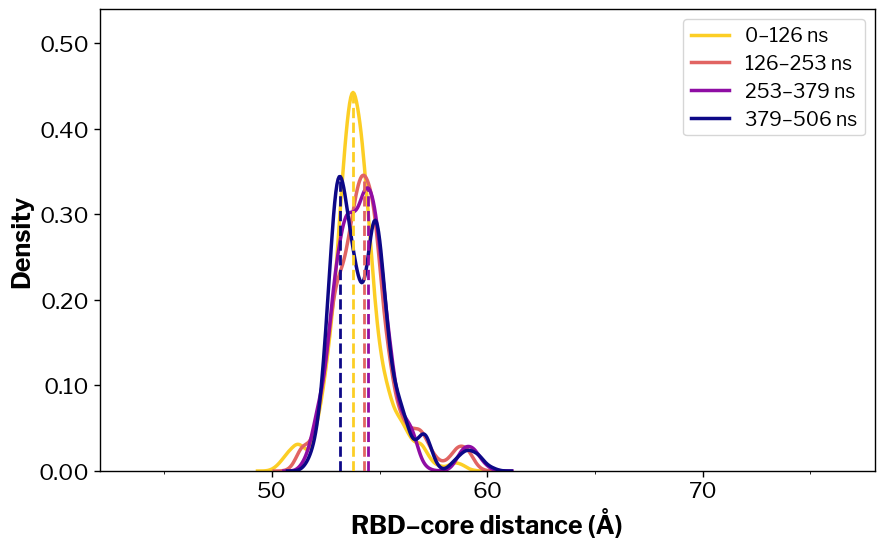

In [15]:
###################################
# RAV RBD–CH — 4 TIME BLOCKS (C)
###################################

# =========================
# USER SETTINGS
# =========================
FRAME_DT_NS = 0.2
BW_ADJUST   = 1.0
X_LIM       = (42, 78)
Y_LIM       = (0, 0.54)
LINEWIDTH   = 2.5

# FONT
# =========================
params = {'font.sans-serif': 'Libre Franklin'}
pylab.rcParams.update(params)

fig, ax = plt.subplots()

# DATA — CHAIN C
# =========================
blocks = [block1_C, block2_C, block3_C, block4_C]

# TIME LABELS (ns)
# =========================
block_ns = block_size * FRAME_DT_NS
labels = [
    f"{0:.0f}–{block_ns:.0f} ns",
    f"{block_ns:.0f}–{2*block_ns:.0f} ns",
    f"{2*block_ns:.0f}–{3*block_ns:.0f} ns",
    f"{3*block_ns:.0f}–{4*block_ns:.0f} ns",
]

# COLORS — PLASMA_R (TRUNCATED)
# =========================
base_cmap = mpl.colormaps["plasma_r"]
sample_points = np.linspace(0.1, 1.0, 4)
colors = [base_cmap(p) for p in sample_points]

# KDE PLOTS — LINES ONLY
# =========================
for block, label, color in zip(blocks, labels, colors):
    sns.kdeplot(
        block,
        fill=False,
        color=color,
        bw_adjust=BW_ADJUST,
        linewidth=LINEWIDTH,
        label=label,
        ax=ax
    )

# PEAKS — HIGHEST + SECOND
# =========================
for line in ax.lines:
    xs = line.get_xdata()
    ys = line.get_ydata()

    peaks, _ = find_peaks(ys)
    if len(peaks) == 0:
        continue

    sorted_peaks = peaks[np.argsort(ys[peaks])[::-1]]

    ax.vlines(
        xs[sorted_peaks[0]], 0, ys[sorted_peaks[0]],
        linestyle='dashed', color=line.get_color(), lw=2, zorder=10
    )

    
# AXES STYLING
# =========================
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1)

ax.set_xlabel("RBD–core distance (Å)", size=18)
ax.set_ylabel("Density", size=18)
ax.set_xlim(X_LIM)
ax.set_ylim(Y_LIM)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(5))
ax.tick_params(which='major', labelsize=16, width=1, length=4)
plt.rcParams["axes.labelweight"] = "bold"

# LEGEND & SAVE
# =========================
ax.legend(loc='upper right', prop={'size': 14})
fig.set_size_inches(10, 6)
fig.savefig(
    path_out + "/RBD_CH_RAV_4timeblocks_chainC_plasmaR_lines.png",
    bbox_inches="tight",
    transparent=True,
    dpi=600
)